# Exploratory Data Analysis — NHANES Diabetes Dataset

This notebook explores the analysis-ready dataset produced by `02_data_preparation.ipynb`.
The goal is to understand distributions, missingness, class balance, and predictor–outcome
relationships before any modelling decisions are made.

**Sections**
1. Dataset overview
2. Outcome: class distribution and cycle breakdown
3. Missingness profile
4. Demographic profile
5. Anthropometrics and blood pressure
6. Cardiometabolic markers
7. Lifestyle: sleep and mental health
8. Physical activity
9. Dietary intake
10. Categorical risk factor prevalence
11. Correlation analysis

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.labelsize":   11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
    "legend.frameon":   False,
})
sns.set_style("ticks")
sns.set_context("notebook", font_scale=1.05)

C0 = "#4C72B0"   # blue   — non-diabetic
C1 = "#DD8452"   # orange — diabetic
COLORS = {0: C0, 1: C1}
LABELS = {0: "Non-diabetic", 1: "Diabetic"}
ALPHA  = 0.60

## Column Groups

In [2]:
# Continuous predictors — used for distributions and correlation analysis
CONTINUOUS_COLS = [
    "age", "income_poverty_ratio",
    "bmi", "waist_circumference",
    "mean_systolic_bp", "mean_diastolic_bp",
    "sleep_hours", "phq9_score",
    "sedentary_minutes_per_day",
    "physical_activity_moderate_equivalent_min_week",
    "total_cholesterol_mg_dl", "hdl_cholesterol_mg_dl",
    "energy_kcal", "protein_g", "carbohydrate_g",
    "total_sugar_g", "fiber_g", "total_fat_g", "cholesterol_mg",
]

# Binary predictors encoded as 1 = Yes, 2 = No
BINARY_COLS = {
    "sex":                               ("Sex", {1: "Male",   2: "Female"}),
    "family_history_diabetes":           ("Family History of Diabetes",     {1: "Yes", 2: "No"}),
    "ever_smoked_100_cigarettes":        ("Ever Smoked 100+ Cigarettes",    {1: "Yes", 2: "No"}),
    "ever_almost_daily_heavy_drinking":  ("Ever Heavy Drinker",             {1: "Yes", 2: "No"}),
    "trouble_sleeping_reported_to_doctor":("Reported Sleep Trouble",        {1: "Yes", 2: "No"}),
    "ever_told_hypertension":            ("Hypertension Diagnosis",         {1: "Yes", 2: "No"}),
    "ever_told_high_cholesterol":        ("High Cholesterol Diagnosis",     {1: "Yes", 2: "No"}),
    "has_health_insurance":              ("Has Health Insurance",            {1: "Yes", 2: "No"}),
    "insurance_gap_past_12_months":      ("Insurance Gap (Past 12 mo.)",    {1: "Yes", 2: "No"}),
    "vigorous_work_activity":            ("Vigorous Work Activity",         {1: "Yes", 2: "No"}),
    "moderate_work_activity":            ("Moderate Work Activity",         {1: "Yes", 2: "No"}),
    "walk_or_bicycle_transport":         ("Walk / Bicycle Transport",       {1: "Yes", 2: "No"}),
    "vigorous_recreational_activity":    ("Vigorous Recreational Activity", {1: "Yes", 2: "No"}),
    "moderate_recreational_activity":    ("Moderate Recreational Activity", {1: "Yes", 2: "No"}),
}

# Ordinal predictors — label maps preserve natural ordering
ORDINAL_COLS = {
    "race_ethnicity": ("Race / Ethnicity", {
        1: "Mexican American", 
        2: "Other Hispanic",
        3: "NH White", 4: "NH Black", 6: "NH Asian", 7: "Other",
    }),
    "education_level": ("Education Level", {
        1: "< 9th Grade", 2: "9–11th Grade",
        3: "HS / GED", 4: "Some College", 5: "College+",
    }),
    "self_rated_health": ("Self-Rated Health", {
        1: "Excellent", 2: "Very Good", 3: "Good", 4: "Fair", 5: "Poor",
    }),
    "adult_food_security_category": ("Adult Food Security", {
        1: "Full", 2: "Marginal", 3: "Low", 4: "Very Low",
    }),
}

## Load Dataset

In [3]:
df = pd.read_parquet("../data/processed/nhanes_analysis_ready.parquet")

# convenience: human-readable diabetes label
df["diabetes_label"] = df["diabetes"].map(LABELS)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Cycles: {sorted(df['cycle'].unique())}")
print(f"\nDtypes summary:")
print(df.dtypes.value_counts())

Shape: 26,000 rows x 44 columns
Cycles: ['2011-2012', '2013-2014', '2015-2016', '2017-March 2020']

Dtypes summary:
float64    41
object      2
Int64       1
Name: count, dtype: int64


## 1 — Dataset Overview

In [4]:
df.head(3)

,participant_id,cycle,diabetes,age,sex,race_ethnicity,education_level,income_poverty_ratio,bmi,waist_circumference,...,total_cholesterol_mg_dl,hdl_cholesterol_mg_dl,energy_kcal,protein_g,carbohydrate_g,total_sugar_g,fiber_g,total_fat_g,cholesterol_mg,diabetes_label
0,62161.0,2011-2012,0,22.0,1.0,3.0,3.0,3.15,23.3,81.0,...,168.0,41.0,2969.0,104.68,359.59,109.09,18.6,123.81,328.0,Non-diabetic
1,62164.0,2011-2012,0,44.0,2.0,3.0,4.0,1.67,23.2,80.1,...,190.0,28.0,1115.0,73.13,91.67,32.29,9.5,51.54,207.0,Non-diabetic
2,62169.0,2011-2012,0,21.0,1.0,6.0,3.0,0.33,20.1,69.6,...,132.0,43.0,1831.0,77.46,297.51,78.19,4.3,34.61,205.0,Non-diabetic


In [5]:
df[CONTINUOUS_COLS].describe().round(2)

,age,income_poverty_ratio,bmi,waist_circumference,mean_systolic_bp,mean_diastolic_bp,sleep_hours,phq9_score,sedentary_minutes_per_day,physical_activity_moderate_equivalent_min_week,total_cholesterol_mg_dl,hdl_cholesterol_mg_dl,energy_kcal,protein_g,carbohydrate_g,total_sugar_g,fiber_g,total_fat_g,cholesterol_mg
count,26000.00,23038.00,24268.00,23168.00,23169.00,23169.00,25872.00,22338.00,25962.00,17445.00,23086.00,23086.00,22321.00,22321.00,22321.00,22321.00,22321.00,22321.00,22321.00
mean,50.11,2.50,29.44,99.84,124.57,71.70,7.34,3.27,423.91,1221.18,188.86,53.17,2115.10,80.81,250.83,108.43,16.88,82.66,304.10
std,17.69,1.64,7.24,16.76,18.66,12.49,2.54,4.36,763.20,3571.43,41.40,16.12,1004.78,43.06,126.45,76.72,10.83,48.01,248.08
min,20.00,0.00,13.40,55.50,64.67,0.00,2.00,0.00,0.00,10.00,59.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35.00,1.08,24.40,87.90,111.33,64.33,6.00,0.00,240.00,180.00,160.00,42.00,1432.00,51.80,164.88,56.82,9.40,49.54,132.00
50%,50.00,2.07,28.20,98.40,122.00,72.00,7.00,2.00,360.00,480.00,186.00,51.00,1944.00,73.08,229.38,92.58,14.50,73.87,234.00
75%,64.00,4.07,33.00,109.70,134.67,79.00,8.00,5.00,480.00,1260.00,214.00,62.00,2603.00,100.59,311.17,140.48,21.80,105.75,410.00
max,80.00,5.00,92.30,187.50,234.67,143.67,99.00,27.00,9999.00,180702.00,813.00,226.00,13687.00,557.87,1815.02,1048.48,136.30,567.96,2968.00


## 2 — Outcome Variable

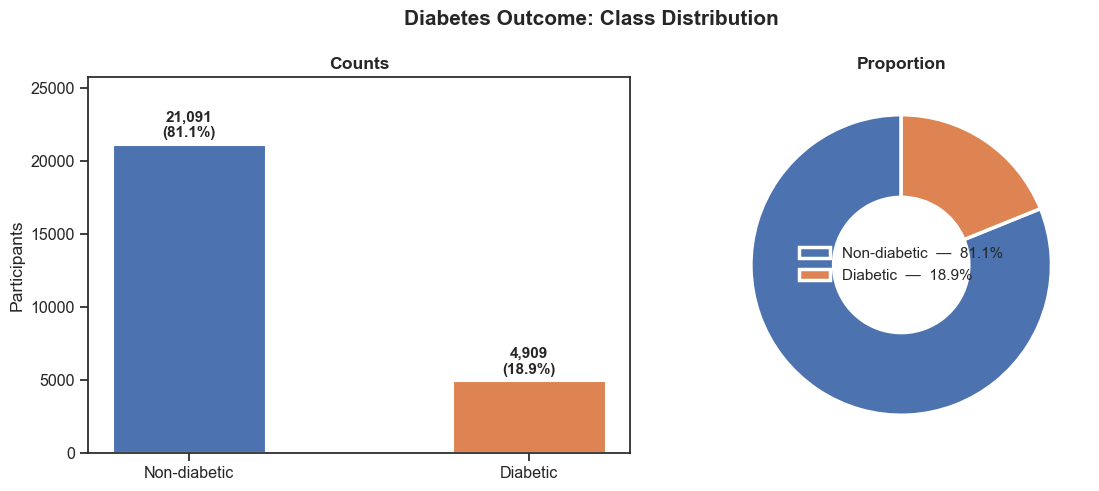

Overall diabetes prevalence: 18.9%


In [ ]:
# ── class distribution ────────────────────────────────────────────────────────
counts = df["diabetes"].value_counts().sort_index()
overall_rate = df["diabetes"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Diabetes Outcome: Class Distribution", fontsize=15, fontweight="bold")

# left — bar chart
ax = axes[0]
bars = ax.bar(
    [LABELS[k] for k in counts.index], counts.values,
    color=[COLORS[k] for k in counts.index],
    width=0.45, edgecolor="white", linewidth=1.5,
)
for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.015,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax.set_ylabel("Participants")
ax.set_ylim(0, counts.max() * 1.22)
ax.set_title("Counts")

# right — donut
ax = axes[1]
wedges, _ = ax.pie(
    counts.values,
    colors=[COLORS[k] for k in counts.index],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5, "width": 0.55},
)
ax.legend(
    wedges,
    [f"{LABELS[k]}  —  {v / counts.sum() * 100:.1f}%" for k, v in zip(counts.index, counts.values)],
    loc="center", fontsize=11,
)
ax.set_title("Proportion")

plt.tight_layout()
plt.show()
print(f"Overall diabetes prevalence: {overall_rate:.1f}%")

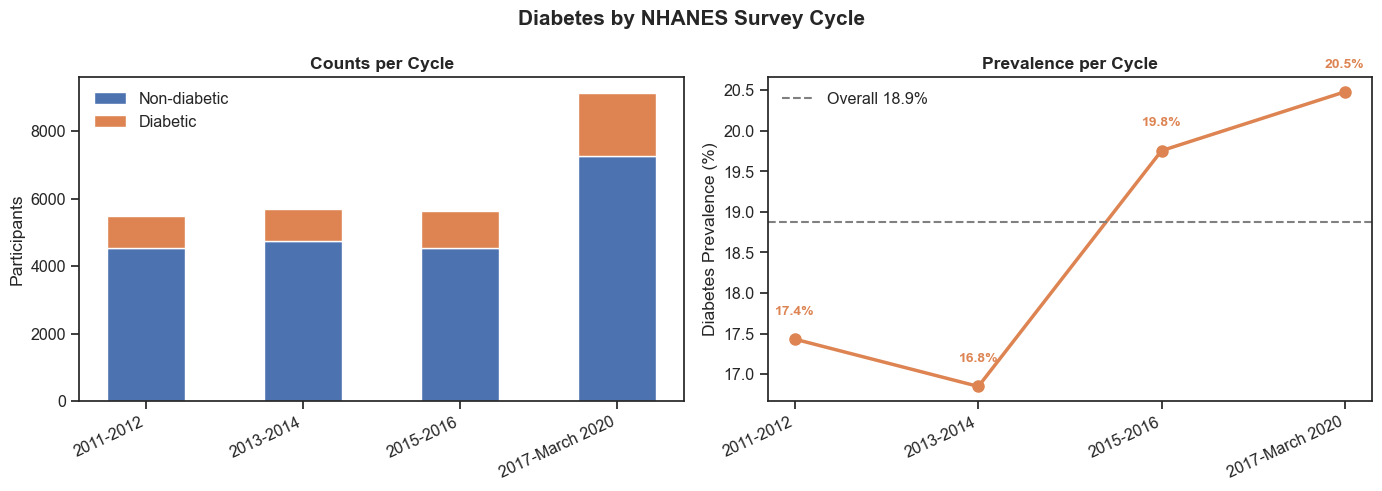

In [7]:
# ── diabetes prevalence by NHANES cycle ───────────────────────────────────────
cycle_stats = (
    df.groupby("cycle")["diabetes"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "diabetic", "count": "total"})
)
cycle_stats["non_diabetic"] = cycle_stats["total"] - cycle_stats["diabetic"]
cycle_stats["prevalence"] = cycle_stats["diabetic"] / cycle_stats["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Diabetes by NHANES Survey Cycle", fontsize=15, fontweight="bold")

# left — stacked bar counts
ax = axes[0]
x = np.arange(len(cycle_stats))
w = 0.5
b1 = ax.bar(x, cycle_stats["non_diabetic"], width=w, color=C0, label="Non-diabetic")
b2 = ax.bar(x, cycle_stats["diabetic"],     width=w, color=C1, label="Diabetic", bottom=cycle_stats["non_diabetic"])
ax.set_xticks(x); ax.set_xticklabels(cycle_stats.index, rotation=25, ha="right")
ax.set_ylabel("Participants"); ax.set_title("Counts per Cycle"); ax.legend()

# right — prevalence line
ax = axes[1]
ax.plot(cycle_stats.index, cycle_stats["prevalence"], marker="o", color=C1, linewidth=2.5, markersize=8)
ax.axhline(overall_rate, color="gray", linestyle="--", linewidth=1.5, label=f"Overall {overall_rate:.1f}%")
for i, (cycle, row) in enumerate(cycle_stats.iterrows()):
    ax.text(i, row["prevalence"] + 0.3, f"{row['prevalence']:.1f}%", ha="center", fontsize=10, color=C1, fontweight="bold")
ax.set_ylabel("Diabetes Prevalence (%)")
ax.set_title("Prevalence per Cycle")
ax.set_xticks(np.arange(len(cycle_stats)))
ax.set_xticklabels(cycle_stats.index, rotation=25, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

## 3 — Missingness Profile

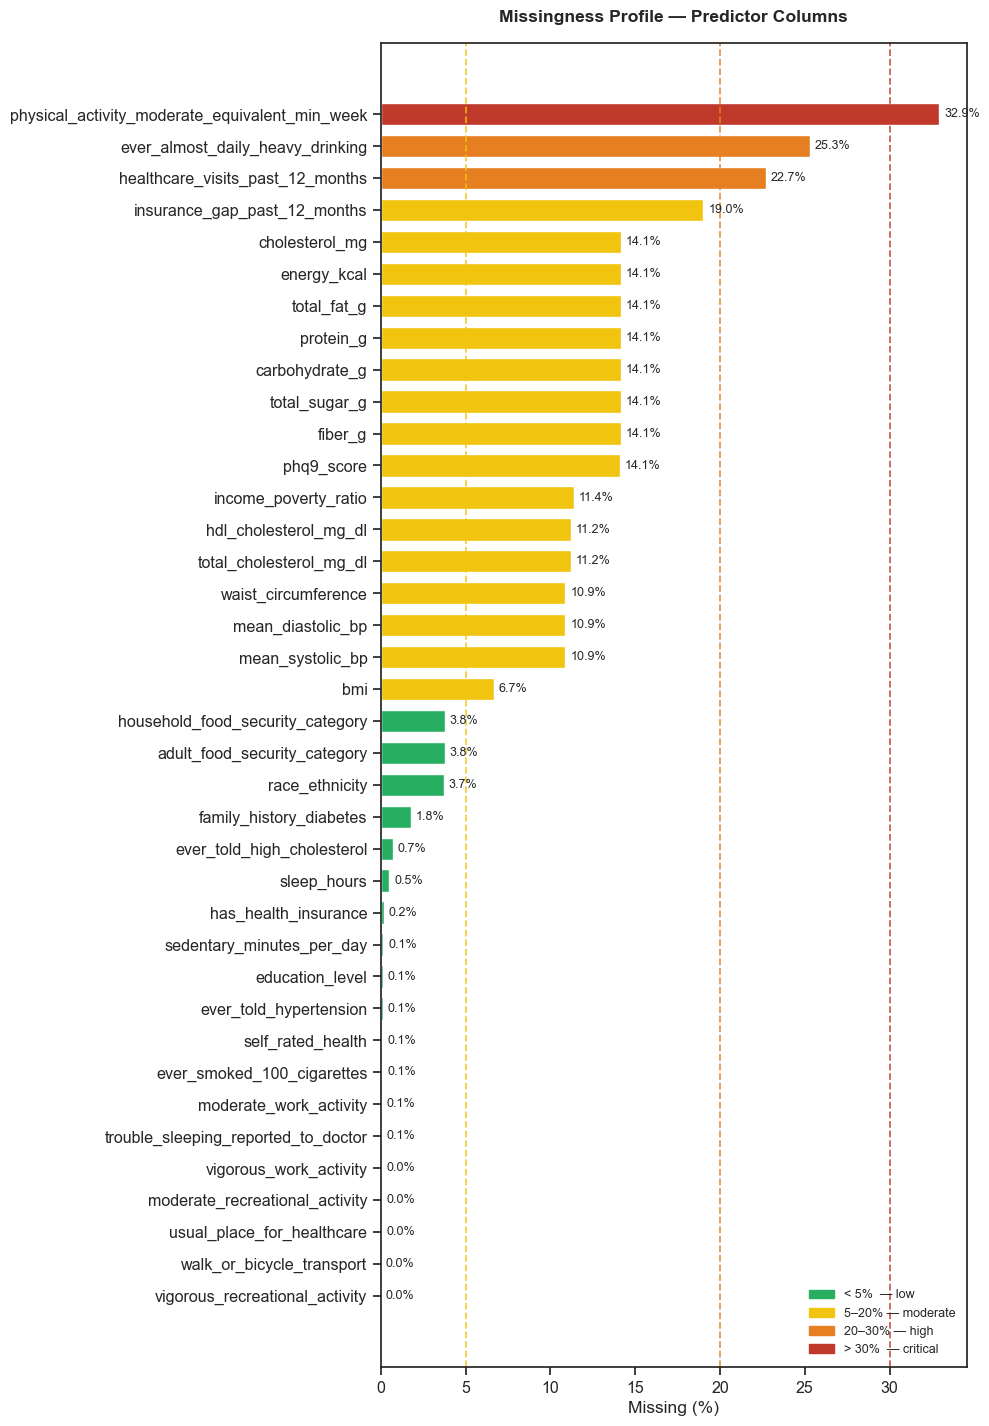

Columns with zero missing: 2 / 40
Columns with >20% missing: 3 / 40


In [8]:
# ── missing rate per predictor column ─────────────────────────────────────────
predictor_cols = [c for c in df.columns if c not in ("participant_id", "cycle", "diabetes", "diabetes_label")]
miss = (df[predictor_cols].isnull().sum() / len(df) * 100).sort_values(ascending=True)
miss_nonzero = miss[miss > 0]

def miss_color(p):
    if p >= 30: return "#C0392B"
    if p >= 20: return "#E67E22"
    if p >=  5: return "#F1C40F"
    return "#27AE60"

colors_miss = [miss_color(p) for p in miss_nonzero]

fig, ax = plt.subplots(figsize=(10, max(5, len(miss_nonzero) * 0.38)))
bars = ax.barh(miss_nonzero.index, miss_nonzero.values, color=colors_miss, edgecolor="white", height=0.7)
ax.axvline(5,  color="#F1C40F", linestyle="--", linewidth=1.3, alpha=0.8)
ax.axvline(20, color="#E67E22", linestyle="--", linewidth=1.3, alpha=0.8)
ax.axvline(30, color="#C0392B", linestyle="--", linewidth=1.3, alpha=0.8)
for bar, val in zip(bars, miss_nonzero.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)

legend_patches = [
    mpatches.Patch(color="#27AE60", label="< 5%  — low"),
    mpatches.Patch(color="#F1C40F", label="5–20% — moderate"),
    mpatches.Patch(color="#E67E22", label="20–30% — high"),
    mpatches.Patch(color="#C0392B", label="> 30%  — critical"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.set_xlabel("Missing (%)")
ax.set_title("Missingness Profile — Predictor Columns", pad=15)
plt.tight_layout()
plt.show()
print(f"Columns with zero missing: {(miss == 0).sum()} / {len(miss)}")
print(f"Columns with >20% missing: {(miss > 20).sum()} / {len(miss)}")

## 4 — Demographic Profile

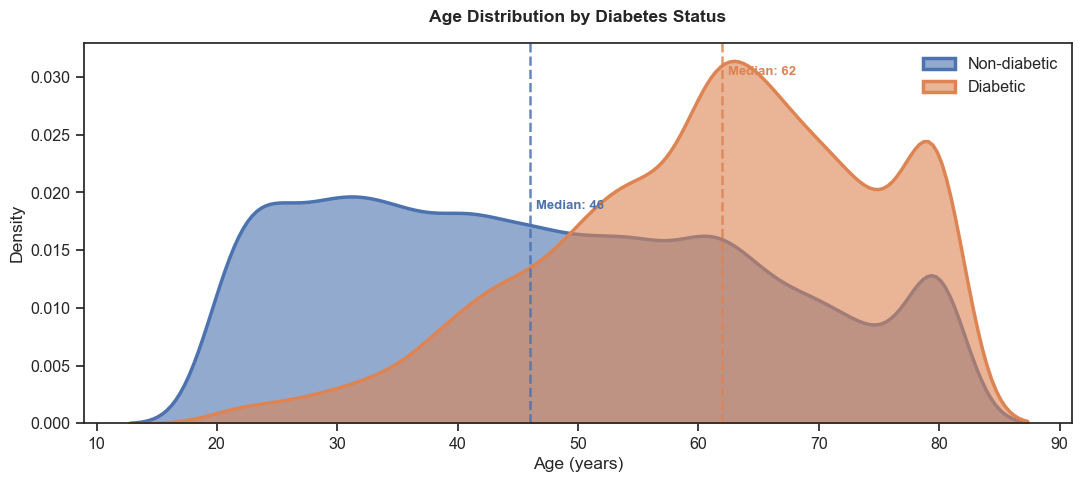

In [9]:
# ── age distribution by diabetes status ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for label_val, grp in df.groupby("diabetes"):
    data = grp["age"].dropna()
    sns.kdeplot(data, ax=ax, label=LABELS[label_val], color=COLORS[label_val],
                fill=True, alpha=ALPHA, linewidth=2.5)
    med = data.median()
    ax.axvline(med, color=COLORS[label_val], linestyle="--", linewidth=1.8, alpha=0.85)
    ymax = ax.get_ylim()[1]
    ax.text(med + 0.5, ymax * 0.94, f"Median: {med:.0f}", color=COLORS[label_val],
            fontsize=9.5, va="top", fontweight="bold")

ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
ax.set_title("Age Distribution by Diabetes Status", pad=15)
ax.legend()
plt.tight_layout()
plt.show()

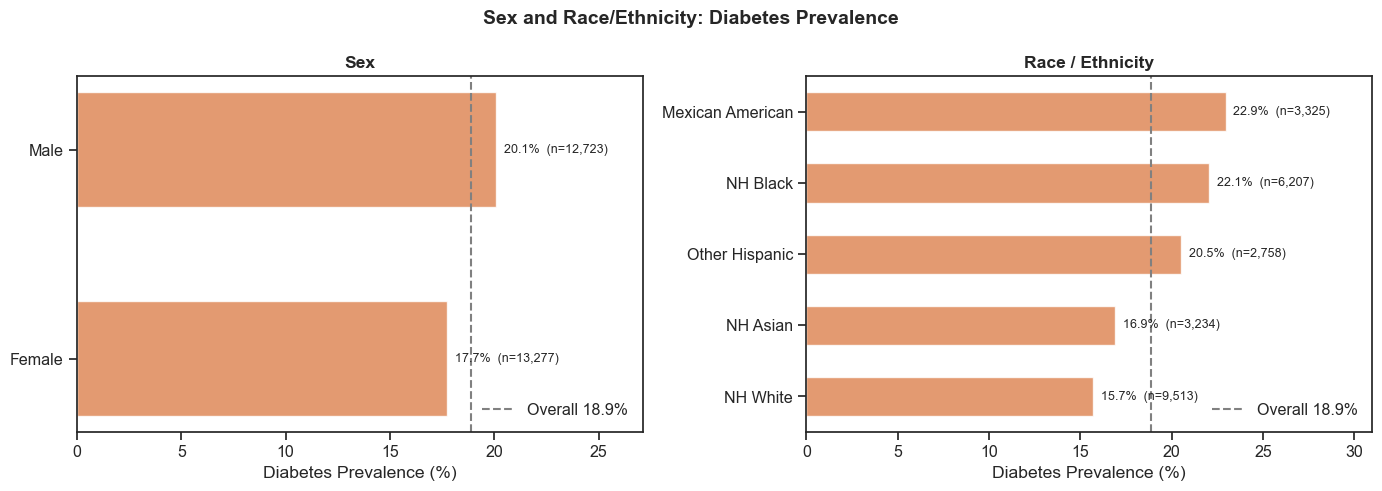

In [11]:
# ── sex and race/ethnicity ─────────────────────────────────────────────────────
race_map  = {1: "Mexican American", 
             2: "Other Hispanic", 3: "NH White",
             4: "NH Black", 6: "NH Asian", 7: "Other"}
sex_map   = {1: "Male", 2: "Female"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sex and Race/Ethnicity: Diabetes Prevalence", fontsize=14, fontweight="bold")

for ax, col, label_map, title in [
    (axes[0], "sex",          sex_map,  "Sex"),
    (axes[1], "race_ethnicity", race_map, "Race / Ethnicity"),
]:
    tmp = df[df[col].notna()].copy()
    tmp["group"] = tmp[col].map(label_map)
    stats = tmp.groupby("group")["diabetes"].agg(["mean", "count"]).reset_index()
    stats["prevalence"] = stats["mean"] * 100
    stats = stats.sort_values("prevalence", ascending=True)

    bars = ax.barh(stats["group"], stats["prevalence"],
                   color=C1, alpha=0.82, edgecolor="white", height=0.55)
    ax.axvline(overall_rate, color="gray", linestyle="--", linewidth=1.5,
               label=f"Overall {overall_rate:.1f}%")
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
                f"{row['prevalence']:.1f}%  (n={int(row['count']):,})",
                va="center", fontsize=9)
    ax.set_xlabel("Diabetes Prevalence (%)")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.set_xlim(0, stats["prevalence"].max() * 1.35)

plt.tight_layout()
plt.show()

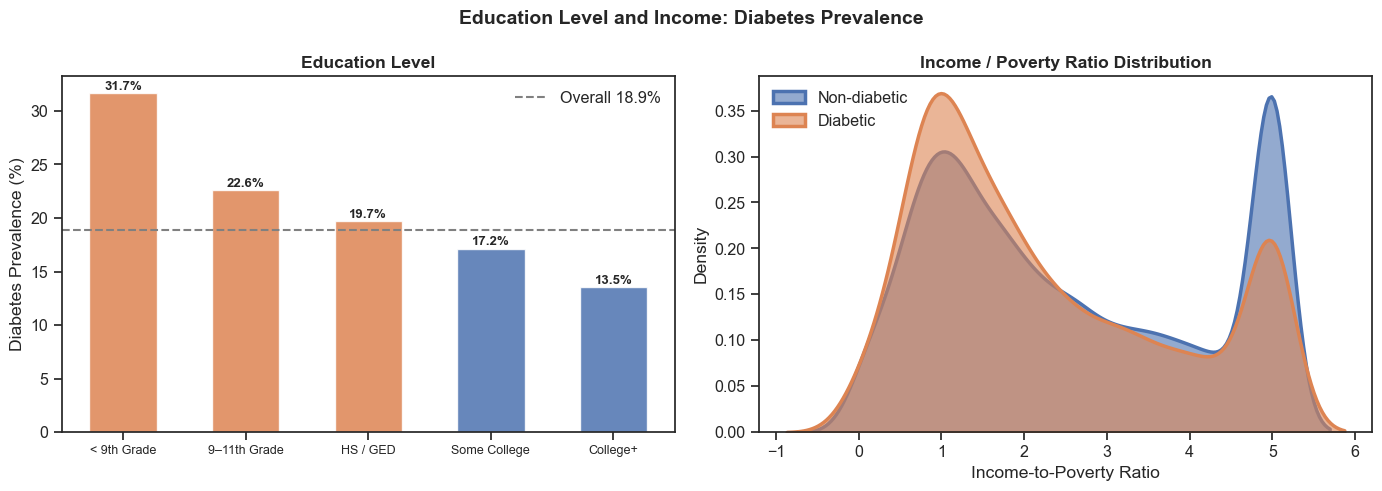

In [12]:
# ── education level and income/poverty ratio ──────────────────────────────────
edu_map = {1: "< 9th Grade", 2: "9–11th Grade", 3: "HS / GED", 4: "Some College", 5: "College+"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Education Level and Income: Diabetes Prevalence", fontsize=14, fontweight="bold")

# left — education bar chart
ax = axes[0]
tmp = df[df["education_level"].notna()].copy()
tmp["edu"] = tmp["education_level"].map(edu_map)
order = [edu_map[k] for k in sorted(edu_map)]
stats = tmp.groupby("edu")["diabetes"].agg(["mean", "count"]).reindex(order).reset_index()
stats["prevalence"] = stats["mean"] * 100
colors_edu = [C1 if p > overall_rate else C0 for p in stats["prevalence"]]
bars = ax.bar(stats["edu"], stats["prevalence"], color=colors_edu, alpha=0.85,
              edgecolor="white", width=0.55)
ax.axhline(overall_rate, color="gray", linestyle="--", linewidth=1.5,
           label=f"Overall {overall_rate:.1f}%")
for bar, val in zip(bars, stats["prevalence"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=9.5, fontweight="bold")
ax.set_ylabel("Diabetes Prevalence (%)")
ax.set_title("Education Level")
ax.tick_params(axis="x", labelsize=9)
ax.legend()

# right — income KDE
ax = axes[1]
for label_val, grp in df.groupby("diabetes"):
    data = grp["income_poverty_ratio"].dropna()
    sns.kdeplot(data, ax=ax, label=LABELS[label_val], color=COLORS[label_val],
                fill=True, alpha=ALPHA, linewidth=2.5)
ax.set_xlabel("Income-to-Poverty Ratio")
ax.set_ylabel("Density")
ax.set_title("Income / Poverty Ratio Distribution")
ax.legend()

plt.tight_layout()
plt.show()

## 5 — Anthropometrics and Blood Pressure

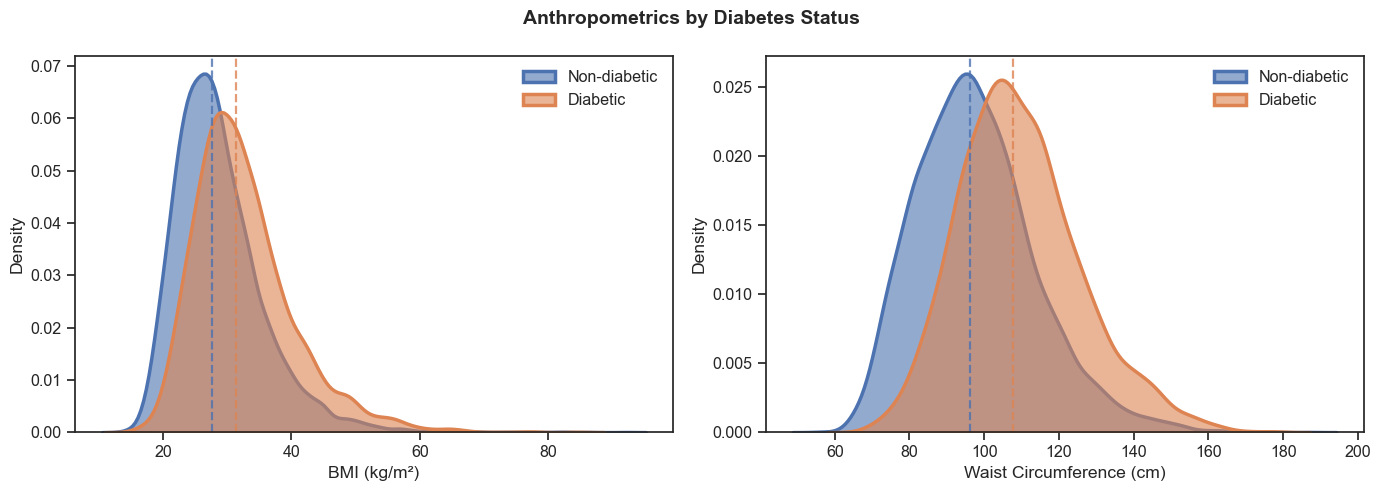

In [13]:
# ── BMI and waist circumference KDE ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Anthropometrics by Diabetes Status", fontsize=14, fontweight="bold")

for ax, col, xlabel in [
    (axes[0], "bmi",                "BMI (kg/m²)"),
    (axes[1], "waist_circumference","Waist Circumference (cm)"),
]:
    for label_val, grp in df.groupby("diabetes"):
        data = grp[col].dropna()
        sns.kdeplot(data, ax=ax, label=LABELS[label_val], color=COLORS[label_val],
                    fill=True, alpha=ALPHA, linewidth=2.5)
        med = data.median()
        ax.axvline(med, color=COLORS[label_val], linestyle="--", linewidth=1.6, alpha=0.8)
    ax.set_xlabel(xlabel); ax.set_ylabel("Density"); ax.legend()

plt.tight_layout()
plt.show()

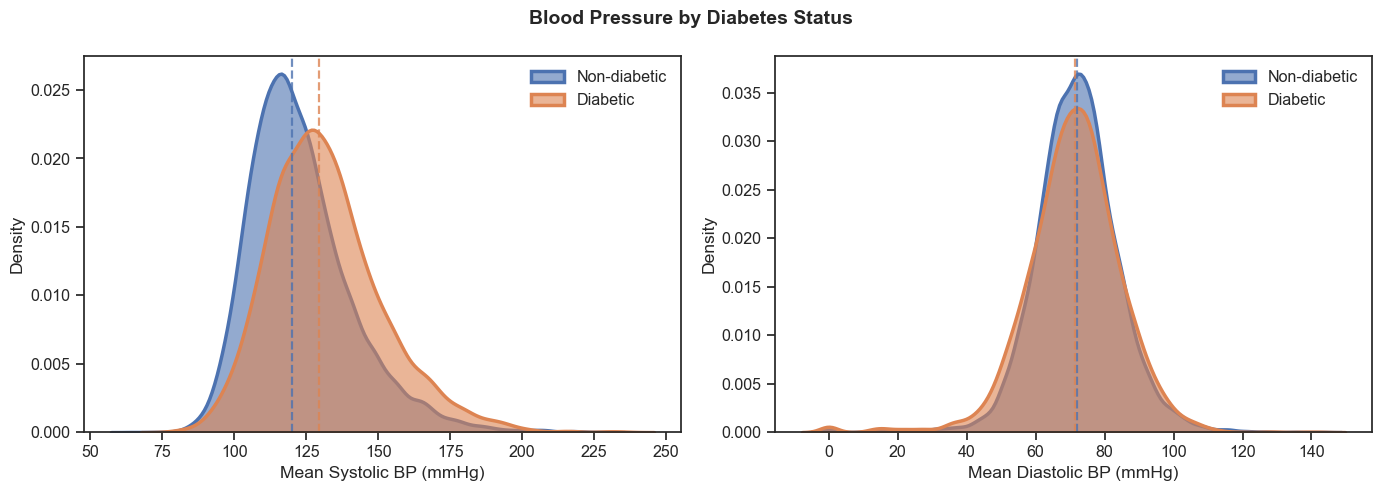

In [14]:
# ── blood pressure KDE ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Blood Pressure by Diabetes Status", fontsize=14, fontweight="bold")

for ax, col, xlabel in [
    (axes[0], "mean_systolic_bp",  "Mean Systolic BP (mmHg)"),
    (axes[1], "mean_diastolic_bp", "Mean Diastolic BP (mmHg)"),
]:
    for label_val, grp in df.groupby("diabetes"):
        data = grp[col].dropna()
        sns.kdeplot(data, ax=ax, label=LABELS[label_val], color=COLORS[label_val],
                    fill=True, alpha=ALPHA, linewidth=2.5)
        med = data.median()
        ax.axvline(med, color=COLORS[label_val], linestyle="--", linewidth=1.6, alpha=0.8)
    ax.set_xlabel(xlabel); ax.set_ylabel("Density"); ax.legend()

plt.tight_layout()
plt.show()

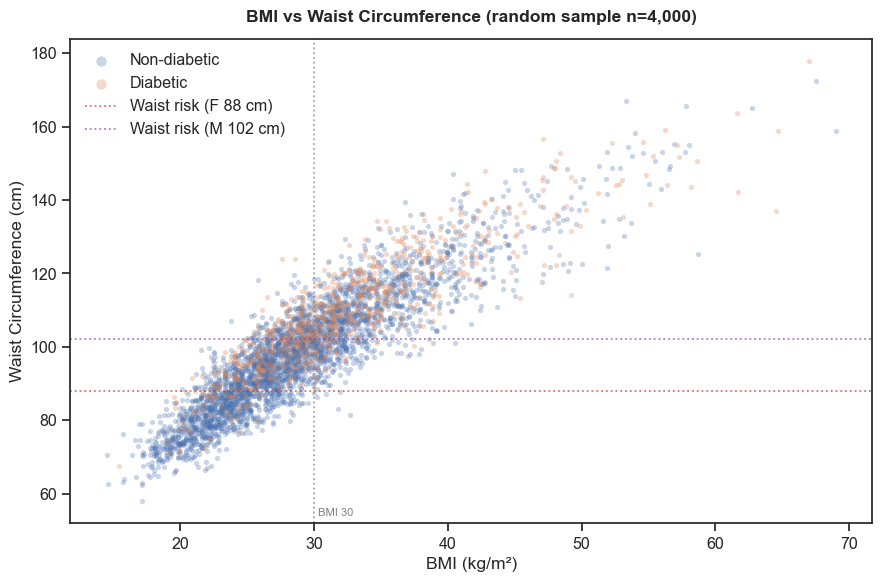

In [15]:
# ── BMI vs waist circumference scatter, coloured by diabetes ─────────────────
sample = df[["bmi", "waist_circumference", "diabetes"]].dropna().sample(
    n=min(4000, len(df)), random_state=42
)

fig, ax = plt.subplots(figsize=(9, 6))
for label_val, grp in sample.groupby("diabetes"):
    ax.scatter(grp["bmi"], grp["waist_circumference"],
               label=LABELS[label_val], color=COLORS[label_val],
               alpha=0.30, s=14, linewidths=0)

# obesity threshold lines
ax.axvline(30, color="gray", linestyle=":", linewidth=1.3, alpha=0.7)
ax.axhline(88, color="#C0392B", linestyle=":", linewidth=1.3, alpha=0.7, label="Waist risk (F 88 cm)")
ax.axhline(102, color="#8E44AD", linestyle=":", linewidth=1.3, alpha=0.7, label="Waist risk (M 102 cm)")
ax.text(30.3, ax.get_ylim()[0] + 2, "BMI 30", fontsize=8, color="gray")

ax.set_xlabel("BMI (kg/m²)")
ax.set_ylabel("Waist Circumference (cm)")
ax.set_title("BMI vs Waist Circumference (random sample n=4,000)", pad=12)
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

## 6 — Cardiometabolic Markers

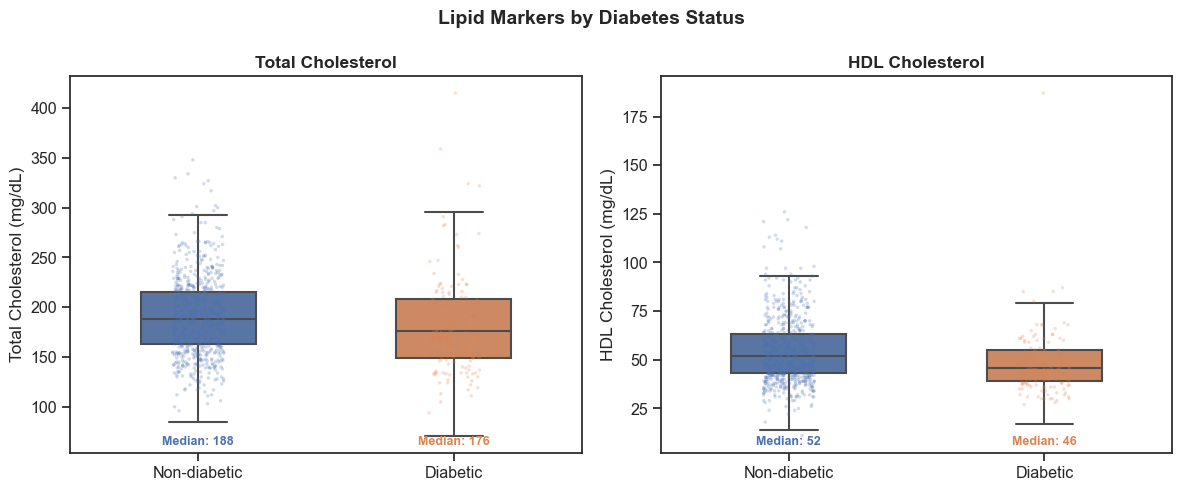

In [16]:
# ── lipid markers boxplots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Lipid Markers by Diabetes Status", fontsize=14, fontweight="bold")

for ax, col, ylabel, unit in [
    (axes[0], "total_cholesterol_mg_dl", "Total Cholesterol", "mg/dL"),
    (axes[1], "hdl_cholesterol_mg_dl",   "HDL Cholesterol",   "mg/dL"),
]:
    plot_data = df[["diabetes_label", col]].dropna()
    order = [LABELS[0], LABELS[1]]
    sns.boxplot(data=plot_data, x="diabetes_label", y=col, order=order,
                palette={LABELS[k]: COLORS[k] for k in COLORS},
                showfliers=False, width=0.45, linewidth=1.5, ax=ax)
    sns.stripplot(data=plot_data.sample(min(800, len(plot_data)), random_state=1),
                  x="diabetes_label", y=col, order=order,
                  palette={LABELS[k]: COLORS[k] for k in COLORS},
                  alpha=0.25, size=2.5, jitter=True, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(f"{ylabel} ({unit})")
    ax.set_title(ylabel)

    # annotate medians
    for i, lbl in enumerate(order):
        med = plot_data[plot_data["diabetes_label"] == lbl][col].median()
        ax.text(i, ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02,
                f"Median: {med:.0f}", ha="center", fontsize=9, fontweight="bold",
                color=[COLORS[k] for k, v in LABELS.items() if v == lbl][0])

plt.tight_layout()
plt.show()

## 7 — Lifestyle: Sleep and Mental Health

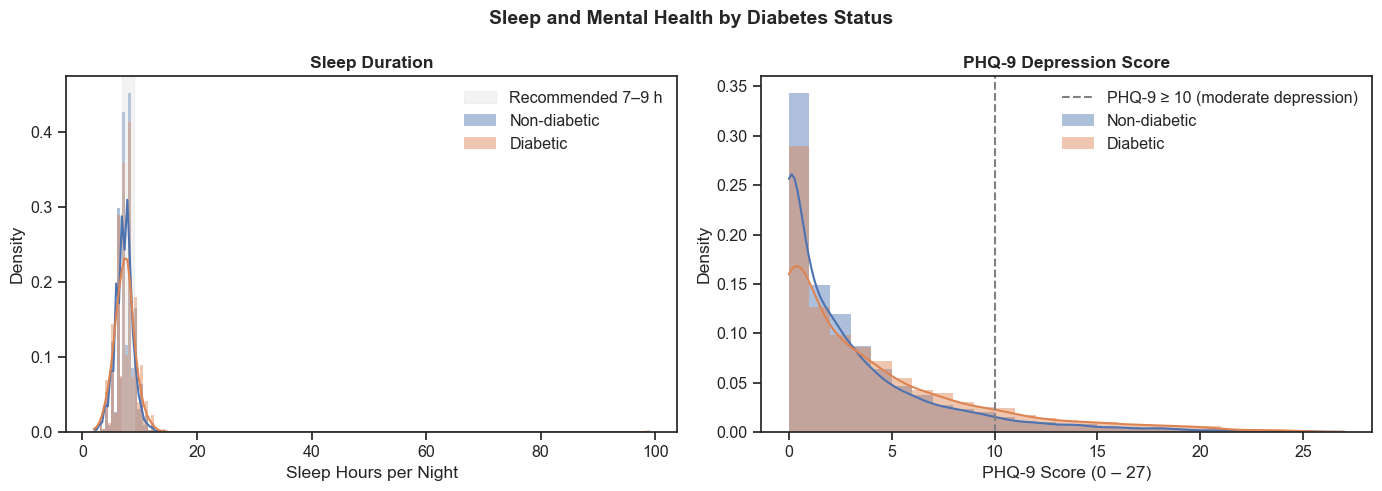

In [17]:
# ── sleep hours and PHQ-9 score distributions ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sleep and Mental Health by Diabetes Status", fontsize=14, fontweight="bold")

# left — sleep hours
ax = axes[0]
for label_val, grp in df.groupby("diabetes"):
    data = grp["sleep_hours"].dropna()
    sns.histplot(data, ax=ax, label=LABELS[label_val], color=COLORS[label_val],
                 kde=True, stat="density", alpha=0.45, binwidth=0.5, linewidth=0)
ax.set_xlabel("Sleep Hours per Night")
ax.set_ylabel("Density")
ax.set_title("Sleep Duration")
ax.axvspan(7, 9, color="lightgray", alpha=0.25, label="Recommended 7–9 h")
ax.legend()

# right — PHQ-9 score
ax = axes[1]
for label_val, grp in df.groupby("diabetes"):
    data = grp["phq9_score"].dropna()
    sns.histplot(data, ax=ax, label=LABELS[label_val], color=COLORS[label_val],
                 kde=True, stat="density", alpha=0.45, binwidth=1, linewidth=0)
ax.axvline(10, color="gray", linestyle="--", linewidth=1.5, label="PHQ-9 ≥ 10 (moderate depression)")
ax.set_xlabel("PHQ-9 Score (0 – 27)")
ax.set_ylabel("Density")
ax.set_title("PHQ-9 Depression Score")
ax.legend()

plt.tight_layout()
plt.show()

## 8 — Physical Activity

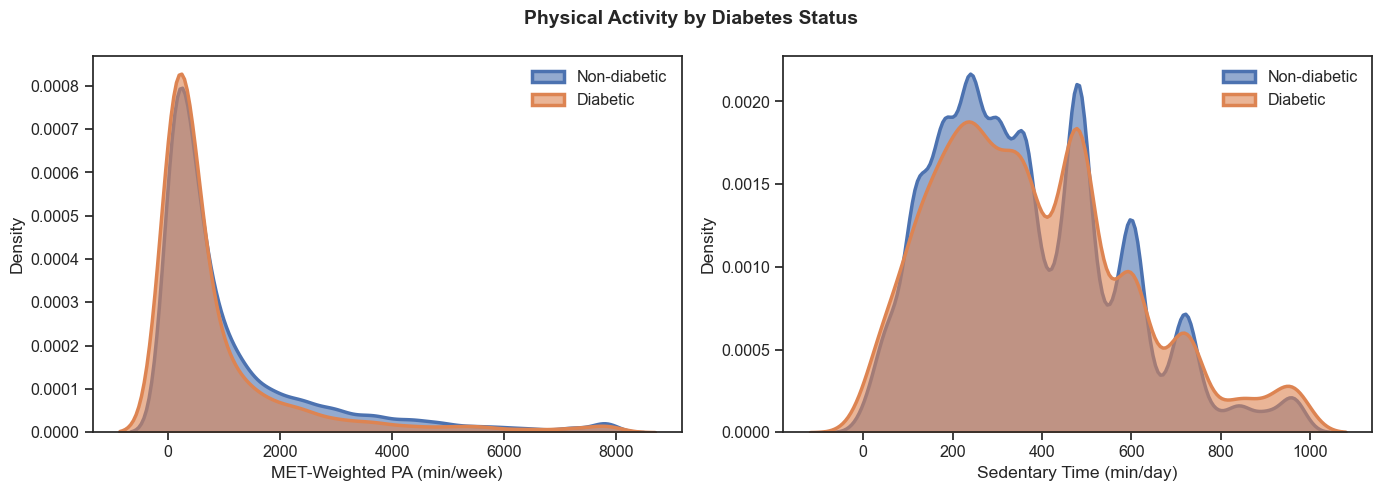

In [18]:
# ── PA summary and sedentary time ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Physical Activity by Diabetes Status", fontsize=14, fontweight="bold")

for ax, col, xlabel, clip_pct in [
    (axes[0], "physical_activity_moderate_equivalent_min_week",
     "MET-Weighted PA (min/week)", 99),
    (axes[1], "sedentary_minutes_per_day", "Sedentary Time (min/day)", 99),
]:
    clip_val = df[col].quantile(clip_pct / 100)
    for label_val, grp in df.groupby("diabetes"):
        data = grp[col].dropna().clip(upper=clip_val)
        sns.kdeplot(data, ax=ax, label=LABELS[label_val], color=COLORS[label_val],
                    fill=True, alpha=ALPHA, linewidth=2.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

## 9 — Dietary Intake

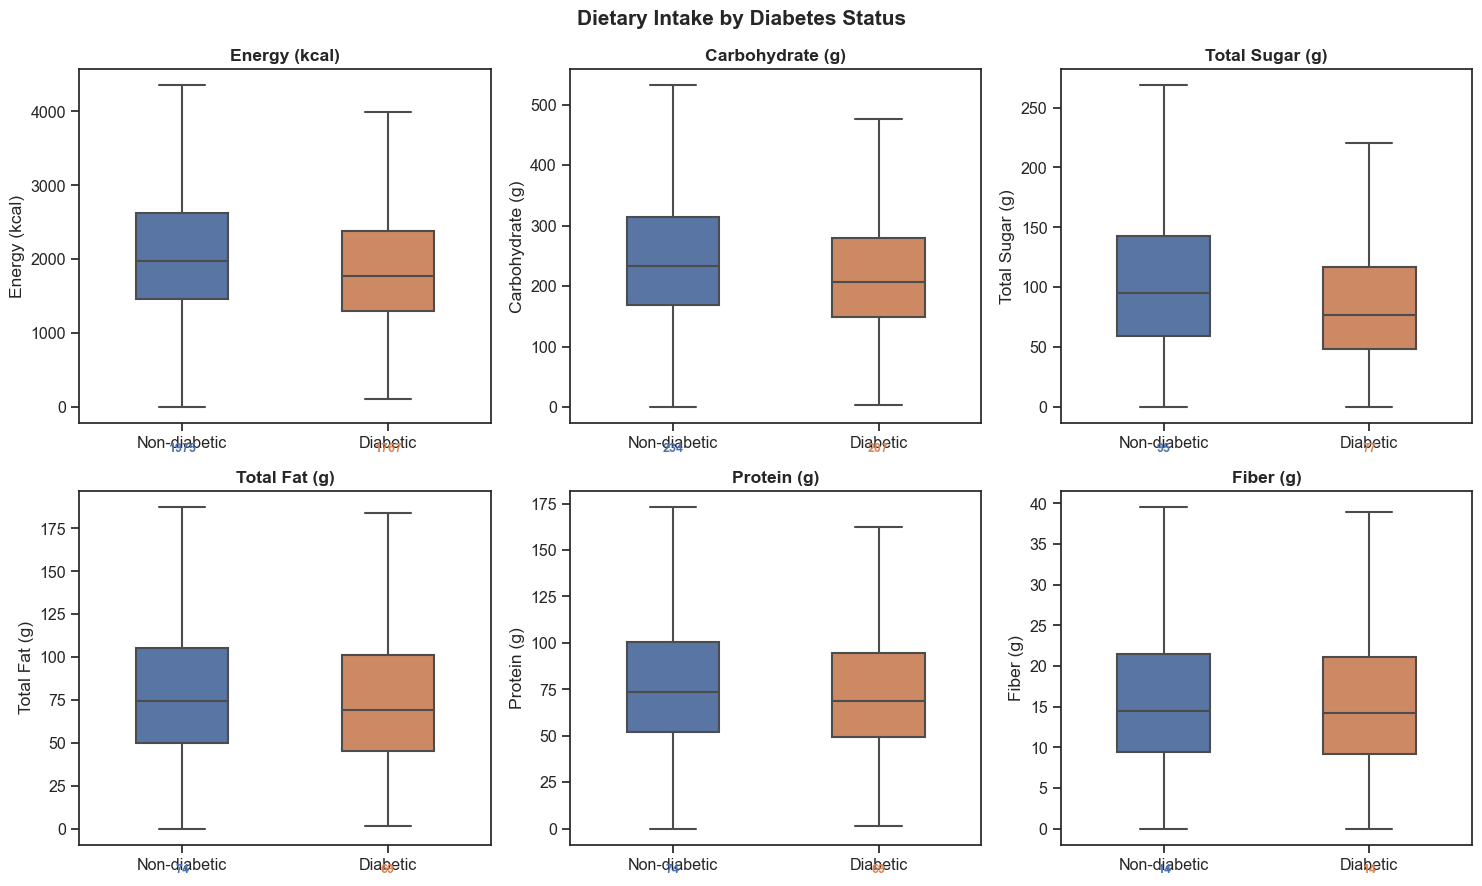

In [19]:
# ── key dietary variables — boxplots ──────────────────────────────────────────
dietary_vars = {
    "energy_kcal":    "Energy (kcal)",
    "carbohydrate_g": "Carbohydrate (g)",
    "total_sugar_g":  "Total Sugar (g)",
    "total_fat_g":    "Total Fat (g)",
    "protein_g":      "Protein (g)",
    "fiber_g":        "Fiber (g)",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Dietary Intake by Diabetes Status", fontsize=15, fontweight="bold")
axes = axes.flatten()
order = [LABELS[0], LABELS[1]]

for ax, (col, label) in zip(axes, dietary_vars.items()):
    plot_data = df[["diabetes_label", col]].dropna()
    clip_val  = plot_data[col].quantile(0.99)
    plot_data = plot_data[plot_data[col] <= clip_val]
    sns.boxplot(data=plot_data, x="diabetes_label", y=col, order=order,
                palette={LABELS[k]: COLORS[k] for k in COLORS},
                showfliers=False, width=0.45, linewidth=1.5, ax=ax)
    for i, lbl in enumerate(order):
        med = plot_data[plot_data["diabetes_label"] == lbl][col].median()
        ax.text(i, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.08,
                f"{med:.0f}", ha="center", fontsize=9, fontweight="bold",
                color=[COLORS[k] for k, v in LABELS.items() if v == lbl][0])
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.show()

## 10 — Categorical Risk Factor Prevalence

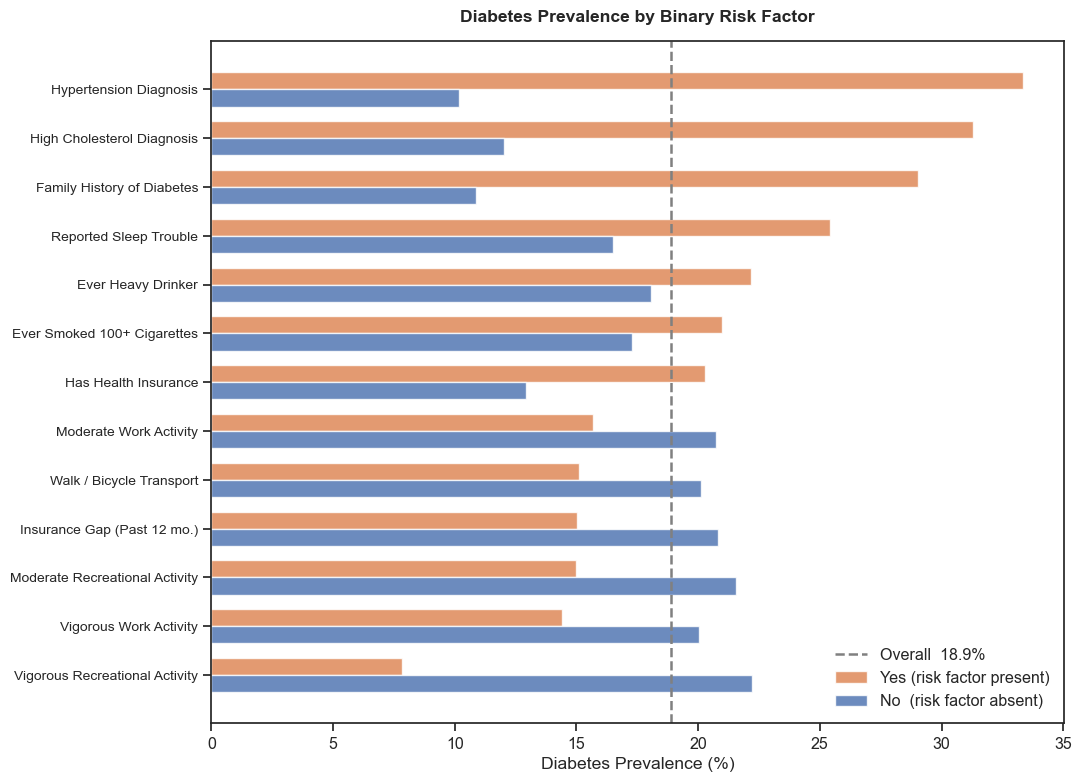

In [20]:
# ── diabetes prevalence for binary predictors ─────────────────────────────────
# For each predictor show diabetes rate when Yes (1) vs No (2)
overall_rate = df["diabetes"].mean() * 100

rows = []
for col, (label, val_map) in BINARY_COLS.items():
    if col == "sex":
        continue  # already covered in demographics
    for raw_val, val_label in val_map.items():
        subset = df[df[col] == raw_val]
        if len(subset) < 30:
            continue
        rate = subset["diabetes"].mean() * 100
        rows.append({
            "predictor": label,
            "category":  val_label,
            "rate":      rate,
            "n":         len(subset),
        })

prev_df = pd.DataFrame(rows)

# pivot so Yes and No are side by side
pivot = prev_df.pivot(index="predictor", columns="category", values="rate").reset_index()

# sort by Yes rate descending
if "Yes" in pivot.columns:
    pivot = pivot.sort_values("Yes", ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
y = np.arange(len(pivot))
h = 0.35

if "Yes" in pivot.columns:
    ax.barh(y + h/2, pivot["Yes"], height=h, color=C1, alpha=0.82, label="Yes (risk factor present)")
if "No" in pivot.columns:
    ax.barh(y - h/2, pivot["No"],  height=h, color=C0, alpha=0.82, label="No  (risk factor absent)")

ax.axvline(overall_rate, color="gray", linestyle="--", linewidth=1.8,
           label=f"Overall  {overall_rate:.1f}%")
ax.set_yticks(y)
ax.set_yticklabels(pivot["predictor"], fontsize=10)
ax.set_xlabel("Diabetes Prevalence (%)")
ax.set_title("Diabetes Prevalence by Binary Risk Factor", pad=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

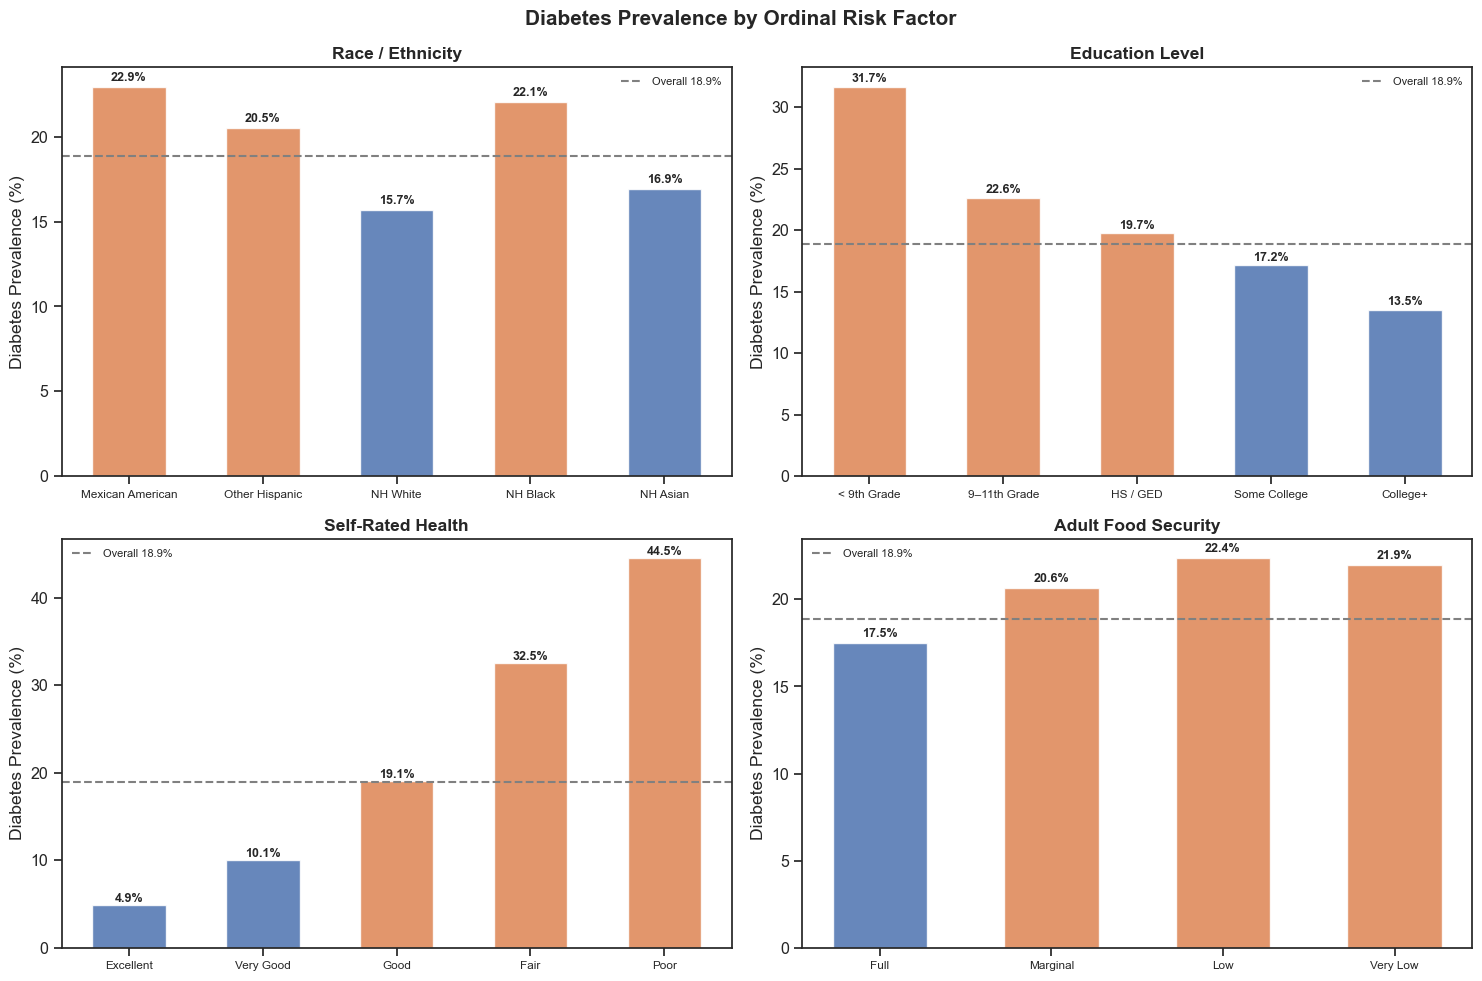

In [22]:
# ── ordinal risk factors ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Diabetes Prevalence by Ordinal Risk Factor", fontsize=15, fontweight="bold")
axes = axes.flatten()

for ax, (col, (title, label_map)) in zip(axes, ORDINAL_COLS.items()):
    tmp = df[df[col].notna()].copy()
    tmp["group"] = tmp[col].map(label_map)

    order = [label_map[k] for k in sorted(label_map.keys())]

    stats = (
        tmp.groupby("group")["diabetes"]
        .agg(["mean", "count"])
        .reindex(order)
        .reset_index()
    )

    stats["prevalence"] = stats["mean"] * 100
    stats = stats.dropna(subset=["prevalence"])

    bar_colors = [C1 if p > overall_rate else C0 for p in stats["prevalence"]]

    bars = ax.bar(
        stats["group"],
        stats["prevalence"],
        color=bar_colors,
        alpha=0.85,
        edgecolor="white",
        width=0.55,
    )

    ax.axhline(
        overall_rate,
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label=f"Overall {overall_rate:.1f}%",
    )

    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.35,
            f"{row['prevalence']:.1f}%",
            ha="center",
            fontsize=9,
            fontweight="bold",
        )

    ax.set_ylabel("Diabetes Prevalence (%)")
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=8.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11 — Correlation Analysis

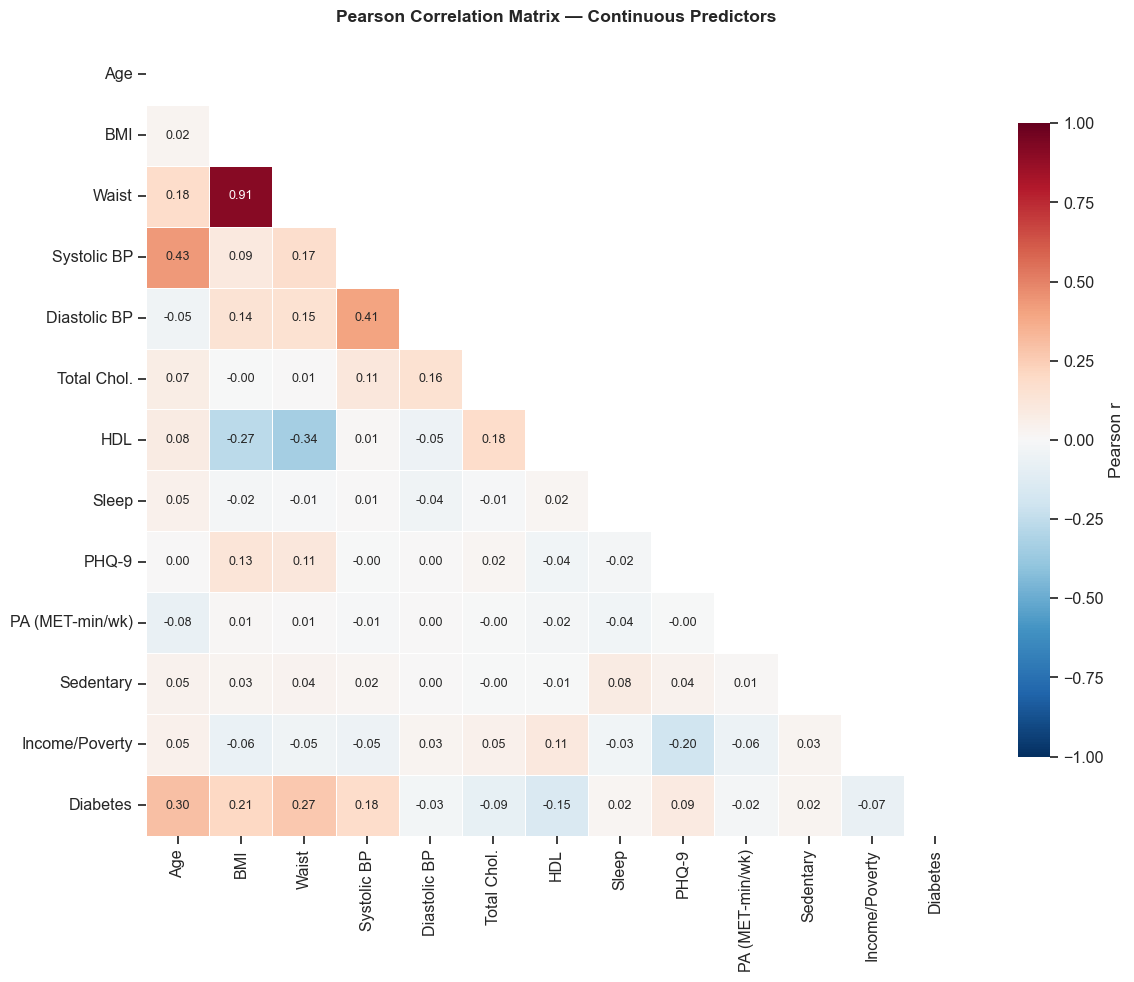


Top correlations with diabetes outcome:
Age                0.300
Waist              0.273
BMI                0.209
Systolic BP        0.181
HDL                0.150
PHQ-9              0.090
Total Chol.        0.086
Income/Poverty     0.071
Diastolic BP       0.027
Sedentary          0.024
PA (MET-min/wk)    0.022
Sleep              0.021


In [23]:
# ── correlation heatmap — continuous predictors + outcome ─────────────────────
CORR_COLS = [
    "age", "bmi", "waist_circumference",
    "mean_systolic_bp", "mean_diastolic_bp",
    "total_cholesterol_mg_dl", "hdl_cholesterol_mg_dl",
    "sleep_hours", "phq9_score",
    "physical_activity_moderate_equivalent_min_week",
    "sedentary_minutes_per_day",
    "income_poverty_ratio",
    "diabetes",
]

corr_matrix = df[CORR_COLS].corr()

# rename for readability in the plot
short_names = {
    "age":                                        "Age",
    "bmi":                                        "BMI",
    "waist_circumference":                        "Waist",
    "mean_systolic_bp":                           "Systolic BP",
    "mean_diastolic_bp":                          "Diastolic BP",
    "total_cholesterol_mg_dl":                    "Total Chol.",
    "hdl_cholesterol_mg_dl":                      "HDL",
    "sleep_hours":                                "Sleep",
    "phq9_score":                                 "PHQ-9",
    "physical_activity_moderate_equivalent_min_week": "PA (MET-min/wk)",
    "sedentary_minutes_per_day":                  "Sedentary",
    "income_poverty_ratio":                       "Income/Poverty",
    "diabetes":                                   "Diabetes",
}
corr_matrix = corr_matrix.rename(index=short_names, columns=short_names)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", linewidths=0.5,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot_kws={"size": 9}, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Pearson Correlation Matrix — Continuous Predictors", pad=16)
plt.tight_layout()
plt.show()

# highlight top correlates with diabetes
diabetes_corr = corr_matrix["Diabetes"].drop("Diabetes").abs().sort_values(ascending=False)
print("\nTop correlations with diabetes outcome:")
print(diabetes_corr.round(3).to_string())